# Understanding the implementation

The high-level `Model` interface hides many of the components available in PyVRP, which uses [an iterated local search algorithm](https://pyvrp.org/dev/algorithm.html) under the hood.
In this notebook we will investigate these components in more detail to build our own `solve` function based on iterated local search.
Along the way we will solve the `RC208.vrp` instance, one of the well-known VRPTW benchmark instances of Solomon.
This instance consists of 100 clients.

In [1]:
from pyvrp import read

INSTANCE = read("data/RC208.vrp", round_func="dimacs")

We will implement a `solve()` function that will take a `stop` stopping criterion, and a `seed` for the random number generator.
This definition is very close to that of `Model.solve`.
The signature is
```python
def solve(stop: StoppingCriterion, seed: int) -> Solution: ...
```

## A tour of PyVRP

We need to understand the separate components in PyVRP before we are ready to implement this function.
PyVRP uses an iterated local search algorithm under the hood.
The `IteratedLocalSearch` object manages a current solution.
In each iteration, the current solution is modified using a method from `pyvrp.search` -- this method should perform both perturbation and improvement steps.
This candidate solution is then considered for acceptance based on a dynamic threshold value.
This process continues until a stopping condition is reached (see `pyvrp.stop` for different conditions).
Let's have a look at the different parts of `pyvrp` that are used to implement this algorithm.

To instantiate the `IteratedLocalSearch`, we need to specify an initial solution, search method, and penalty manager.
Let's start with a random number generator because it is needed to set up the initial solution and search method.

##### Random number generator

In [2]:
from pyvrp import RandomNumberGenerator

rng = RandomNumberGenerator(seed=42)

##### Search method

Let's now define the search method.
The search method applies both perturbation and improvement steps.
PyVRP implements a `LocalSearch` method that is very customisable with different operators and search neighbourhoods.
Different operators search different parts of the solution space, which can be beneficial in finding better solutions.
The search neighbourhood defines which edges are evaluated.
By restricting that set of edges the local search method works much faster.

We provide default operator sets and neighbourhoods, which can be used as follows.

In [3]:
from pyvrp.search import OPERATORS, LocalSearch, compute_neighbours

neighbours = compute_neighbours(INSTANCE)
ls = LocalSearch(INSTANCE, rng, neighbours)

for op in OPERATORS:
    ls.add_operator(op(INSTANCE))

##### Solution representation and evaluation

We now have a functioning local search method.
All we need are two additional components to make it work: an initial `Solution` containing a set of routes, and a `CostEvaluator` that can be used to evaluate different moves.
Let's define those.

In [4]:
from pyvrp import CostEvaluator, Solution

sol = Solution.make_random(INSTANCE, rng)
cost_evaluator = CostEvaluator(
    load_penalties=[20],
    tw_penalty=20,
    dist_penalty=0,
)

The random solution `sol` that we created just yet is not feasible.
This is not a problem, because PyVRP internally uses penalties to evaluate infeasibilities in each solution.
This is done using the `CostEvaluator`'s `penalised_cost` function, which allows us to determine the quality of infeasible solutions as well.

In [5]:
assert not sol.is_feasible()
print(cost_evaluator.penalised_cost(sol))

142556


Let's see if the local search can improve this solution.

In [6]:
new_sol = ls(sol, cost_evaluator, exhaustive=True)

assert not sol.is_feasible()
print(cost_evaluator.penalised_cost(new_sol))

8858


Much better! 
But the new solution is not yet feasible.
Can we hammer out the infeasibilities by increasing the penalties?

In [7]:
cost_evaluator = CostEvaluator([200], 200, 0)
new_sol = ls(sol, cost_evaluator, exhaustive=True)

assert new_sol.is_feasible()

How good is this solution?

In [8]:
print(cost_evaluator.penalised_cost(new_sol))

8731


Pretty good!
This is how PyVRP manages infeasibilities: it adjusts the penalty parameters to ensure sufficiently many solutions are feasible.
Too few feasible solutions and the penalties go up; too many and they go down.
This ensures a balanced search of feasible and infeasible solutions, which is good for exploration.

The object in charge of managing the penalty terms is the `PenaltyManager`, which can be asked to provide a `CostEvaluator` of the form we saw above.

In [9]:
from pyvrp import PenaltyManager

pen_manager = PenaltyManager(initial_penalties=([20], 6, 6))
cost_evaluator = pen_manager.cost_evaluator()

An initial solution can be constructed easily using the random solution constructor:

In [10]:
init_sol = Solution.make_random(INSTANCE, rng)

We are now ready to construct the iterated local search algorithm.

In [11]:
from pyvrp import IteratedLocalSearch

algo = IteratedLocalSearch(INSTANCE, pen_manager, ls, init_sol)

We can call `algo.run`, which iterates until a stopping criterion is met.
These stopping criteria can be imported from `pyvrp.stop` - see [the API documentation](https://pyvrp.org/api/stop.html) for details.

In [12]:
from pyvrp.stop import MaxIterations, MaxRuntime

iter_res = algo.run(stop=MaxIterations(2000))
time_res = algo.run(stop=MaxRuntime(1))  # seconds

Let's investigate the solutions!

In [13]:
print(iter_res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
 # shipments: 0
   objective: 7928
    distance: 7928
    duration: 17928
# iterations: 2000
    run-time: 1.12 seconds

Routes
------
Route #1: C89 C64 C81 C98 C51 C56 C82 C63 C48 C18 C17 C47 C20 C22 C24 C76 C57 C74 C96 C58 C86 C73 C85 C8 C12 C9 C59 C54
Route #2: C60 C80 C93 C92 C70 C71 C40 C41 C43 C42 C39 C35 C34 C36 C37 C38 C53 C95
Route #3: C68 C97 C87 C52 C11 C10 C14 C15 C16 C46 C13 C77 C72 C78 C6 C5 C1 C7 C45 C3 C44 C4 C2 C0 C99 C69 C67
Route #4: C91 C94 C83 C61 C66 C49 C33 C30 C28 C26 C25 C27 C29 C31 C32 C75 C88 C62 C84 C50 C19 C21 C23 C65 C55 C90 C79



In [14]:
print(time_res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
 # shipments: 0
   objective: 7828
    distance: 7828
    duration: 17828
# iterations: 1792
    run-time: 1.00 seconds

Routes
------
Route #1: C89 C81 C98 C51 C85 C86 C58 C74 C57 C76 C24 C22 C20 C47 C17 C18 C48 C19 C21 C23 C56 C73 C96 C12 C9 C59 C54
Route #2: C91 C94 C66 C70 C71 C40 C38 C37 C36 C34 C35 C39 C42 C43 C41 C60 C80 C53 C95 C92 C93 C90 C79
Route #3: C64 C82 C63 C50 C84 C62 C75 C88 C32 C29 C31 C27 C25 C26 C28 C30 C33 C49 C61 C83 C55 C65
Route #4: C68 C97 C87 C52 C8 C10 C14 C15 C16 C46 C13 C11 C77 C72 C78 C6 C5 C1 C7 C45 C3 C44 C4 C2 C0 C99 C69 C67



## The `solve` function

Let's put everything we have learned together into a `solve` function.

In [15]:
def solve(stop, seed):
    rng = RandomNumberGenerator(seed=seed)
    pm = PenaltyManager(initial_penalties=([20], 6, 6))

    neighbours = compute_neighbours(INSTANCE)
    ls = LocalSearch(INSTANCE, rng, neighbours)

    for op in OPERATORS:
        ls.add_operator(op(INSTANCE))

    init = Solution.make_random(INSTANCE, rng)
    algo = IteratedLocalSearch(INSTANCE, pm, ls, init)

    return algo.run(stop)

Very good.
Let's solve the instance again, now using the `solve` function.

In [16]:
res = solve(stop=MaxIterations(2000), seed=1)
print(res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
 # shipments: 0
   objective: 7898
    distance: 7898
    duration: 17898
# iterations: 2000
    run-time: 1.11 seconds

Routes
------
Route #1: C68 C97 C87 C1 C5 C6 C78 C72 C77 C11 C13 C46 C16 C15 C14 C12 C8 C10 C9 C52 C59 C7 C45 C3 C44 C4 C2 C0 C69 C99 C54 C67
Route #2: C89 C64 C81 C98 C51 C82 C63 C48 C18 C17 C47 C20 C22 C24 C76 C57 C74 C96 C58 C86 C73 C85 C56 C23 C21 C19 C65
Route #3: C60 C80 C93 C92 C70 C71 C40 C41 C43 C42 C39 C35 C34 C36 C37 C38 C53 C95
Route #4: C91 C94 C50 C84 C62 C75 C88 C32 C30 C28 C26 C25 C27 C29 C31 C33 C49 C66 C61 C83 C55 C90 C79



PyVRP also provides many plotting tools that can be used to investigate a data instance or solution result.

In [17]:
import matplotlib.pyplot as plt

from pyvrp.plotting import plot_result

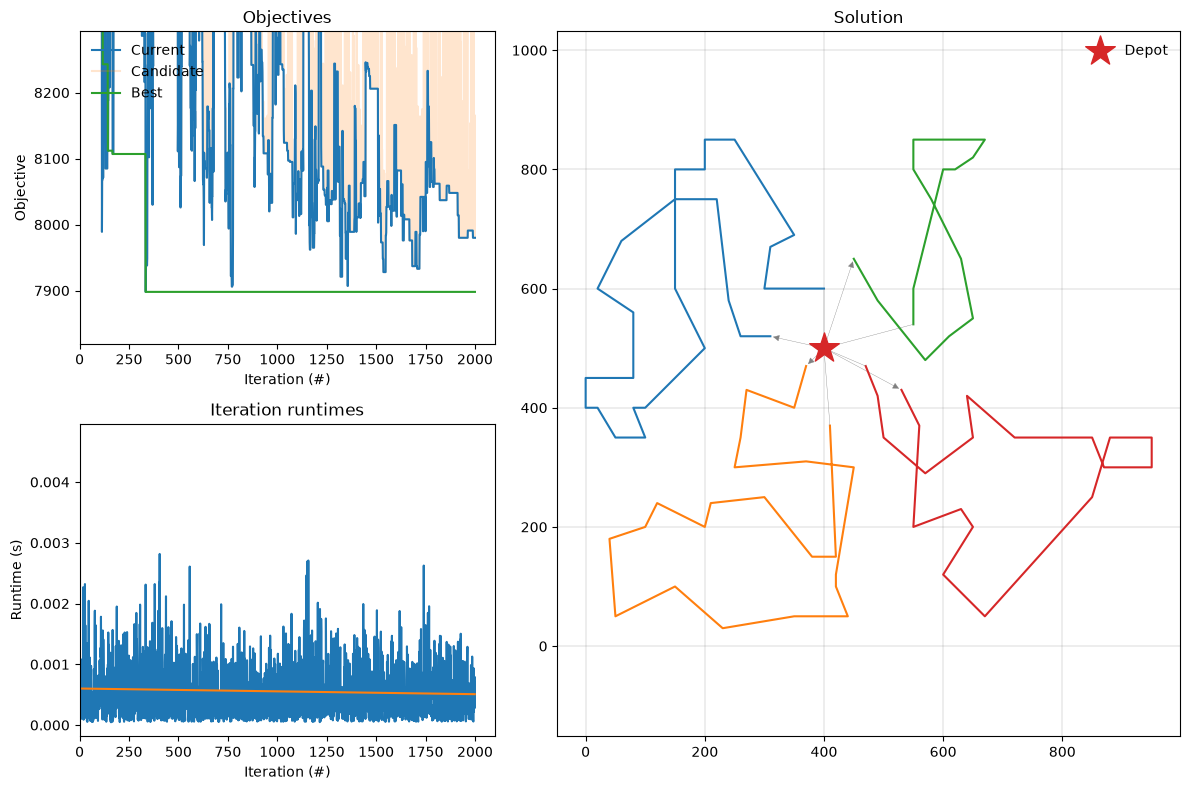

In [18]:
fig = plt.figure(figsize=(12, 8))

plot_result(res, INSTANCE, fig=fig)
plt.tight_layout()

The top-left figure shows the penalised costs of the current, candidate, and best solutions across iterations.
The fluctuations in current solution cost demonstrates the acceptance criterion's strategy: while generally favoring improvements, it occasionally accepts worse solutions to escape local minima.
Meanwhile, the candidate solution cost variations show the perturbation strategy - generating diverse solutions that, although occasionally being significantly worse, are essential to finding superior solutions throughout the search.
The bottom-left figure shows average iteration runtimes (in seconds).
Finally, the figure on the right plots the best observed solution.

## Conclusion

In this notebook we have used some of the different components in PyVRP to implement our own `solve` function.
Along the way we learned about how PyVRP works internally.